# Deep Learning Group Project

**Group ID:** [YOUR_GROUP_ID]

**Team Members:**
- Member 1: [Name]
- Member 2: [Name]
- Member 3: [Name]

**Academic Honesty Statement:**

> *I declare that this submission is my own work, and that I did not use any pretrained model or code that I did not explicitly cite.*

---

## 1. Introduction

### Problem Understanding

We are tasked with building a **multi-output deep learning model** that predicts three independent targets from 32×32 image inputs:

- **Target A**: Classification into 10 classes (digits 0-9)
- **Target B**: Classification into 32 classes (0-31)
- **Target C**: Regression predicting a continuous value in [0,1]

### Goals

1. Design a single CNN architecture with multiple output heads
2. Handle mixed loss functions (classification + regression)
3. Achieve good performance across all three independent tasks
4. Create a reproducible and well-documented solution

### Key Challenges

- Balancing multiple loss functions with different scales
- Designing an architecture that extracts useful features for all three tasks
- Avoiding overfitting with limited data (3000 samples)
- Proper evaluation strategy for multi-task learning

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
Keras version: 3.12.0
GPU available: []


## 2. Dataset Inspection

Let's load and thoroughly inspect our dataset to understand its properties.

In [2]:
# Load the dataset
data = np.load('dataset_dev_3000.npz')
X = data['X']
y = data['y']

print("Dataset Shapes:")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nData Types:")
print(f"X dtype: {X.dtype}")
print(f"y dtype: {y.dtype}")

Dataset Shapes:
X shape: (3000, 32, 32)
y shape: (3000, 3)

Data Types:
X dtype: float32
y dtype: float32


In [3]:
# Examine input data (X) statistics
print("Input Data (X) Statistics:")
print(f"Min: {X.min():.4f}")
print(f"Max: {X.max():.4f}")
print(f"Mean: {X.mean():.4f}")
print(f"Std: {X.std():.4f}")
print(f"\nAny NaN: {np.isnan(X).any()}")
print(f"Any Inf: {np.isinf(X).any()}")

Input Data (X) Statistics:
Min: 0.0001
Max: 6.8486
Mean: 0.8141
Std: 0.7387

Any NaN: False
Any Inf: False


In [4]:
# Examine target data (y) - each column separately
print("Target A (y[:,0]) - Classification (10 classes):")
print(f"Unique values: {np.unique(y[:,0]).astype(int)}")
unique_a, counts_a = np.unique(y[:,0], return_counts=True)
for val, count in zip(unique_a.astype(int), counts_a):
    print(f"  Class {val}: {count} ({count/len(y)*100:.1f}%)")

print("\nTarget B (y[:,1]) - Classification (32 classes):")
print(f"Number of unique values: {len(np.unique(y[:,1]))}")
print(f"Min: {y[:,1].min()}, Max: {y[:,1].max()}")

print("\nTarget C (y[:,2]) - Regression [0,1]:")
print(f"Min: {y[:,2].min():.4f}")
print(f"Max: {y[:,2].max():.4f}")
print(f"Mean: {y[:,2].mean():.4f}")
print(f"Std: {y[:,2].std():.4f}")

Target A (y[:,0]) - Classification (10 classes):
Unique values: [0 1 2 3 4 5 6 7 8 9]
  Class 0: 290 (9.7%)
  Class 1: 304 (10.1%)
  Class 2: 311 (10.4%)
  Class 3: 305 (10.2%)
  Class 4: 306 (10.2%)
  Class 5: 294 (9.8%)
  Class 6: 290 (9.7%)
  Class 7: 291 (9.7%)
  Class 8: 310 (10.3%)
  Class 9: 299 (10.0%)

Target B (y[:,1]) - Classification (32 classes):
Number of unique values: 32
Min: 0.0, Max: 31.0

Target C (y[:,2]) - Regression [0,1]:
Min: 0.0003
Max: 0.9996
Mean: 0.4945
Std: 0.2876


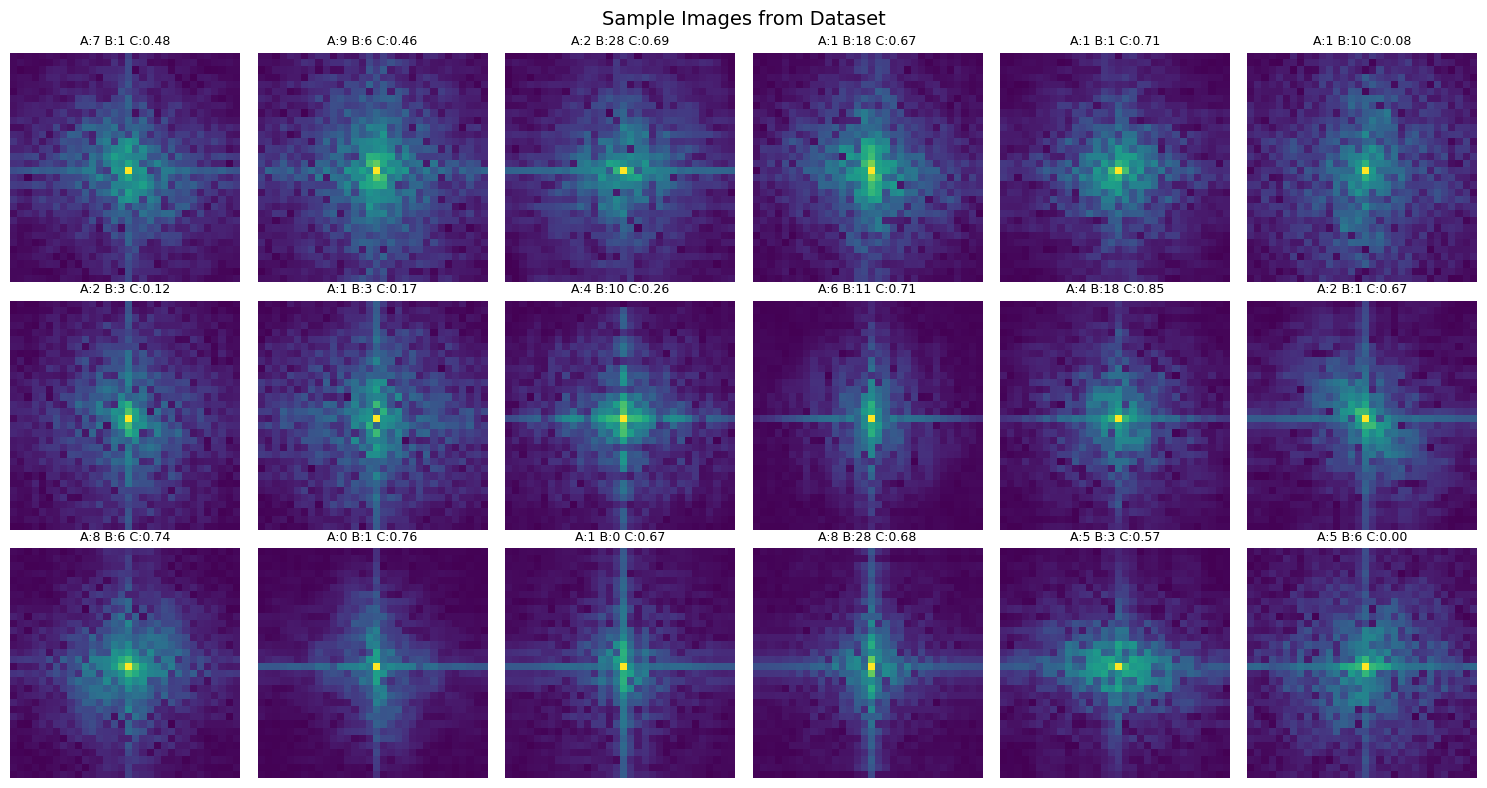

In [5]:
# Visualize sample images
fig, axes = plt.subplots(3, 6, figsize=(15, 8))
axes = axes.ravel()

for i in range(18):
    idx = i * 150  # Sample across the dataset
    axes[i].imshow(X[idx], cmap='viridis')
    axes[i].set_title(f'A:{int(y[idx,0])} B:{int(y[idx,1])} C:{y[idx,2]:.2f}', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Sample Images from Dataset', fontsize=14)
plt.tight_layout()
plt.show()

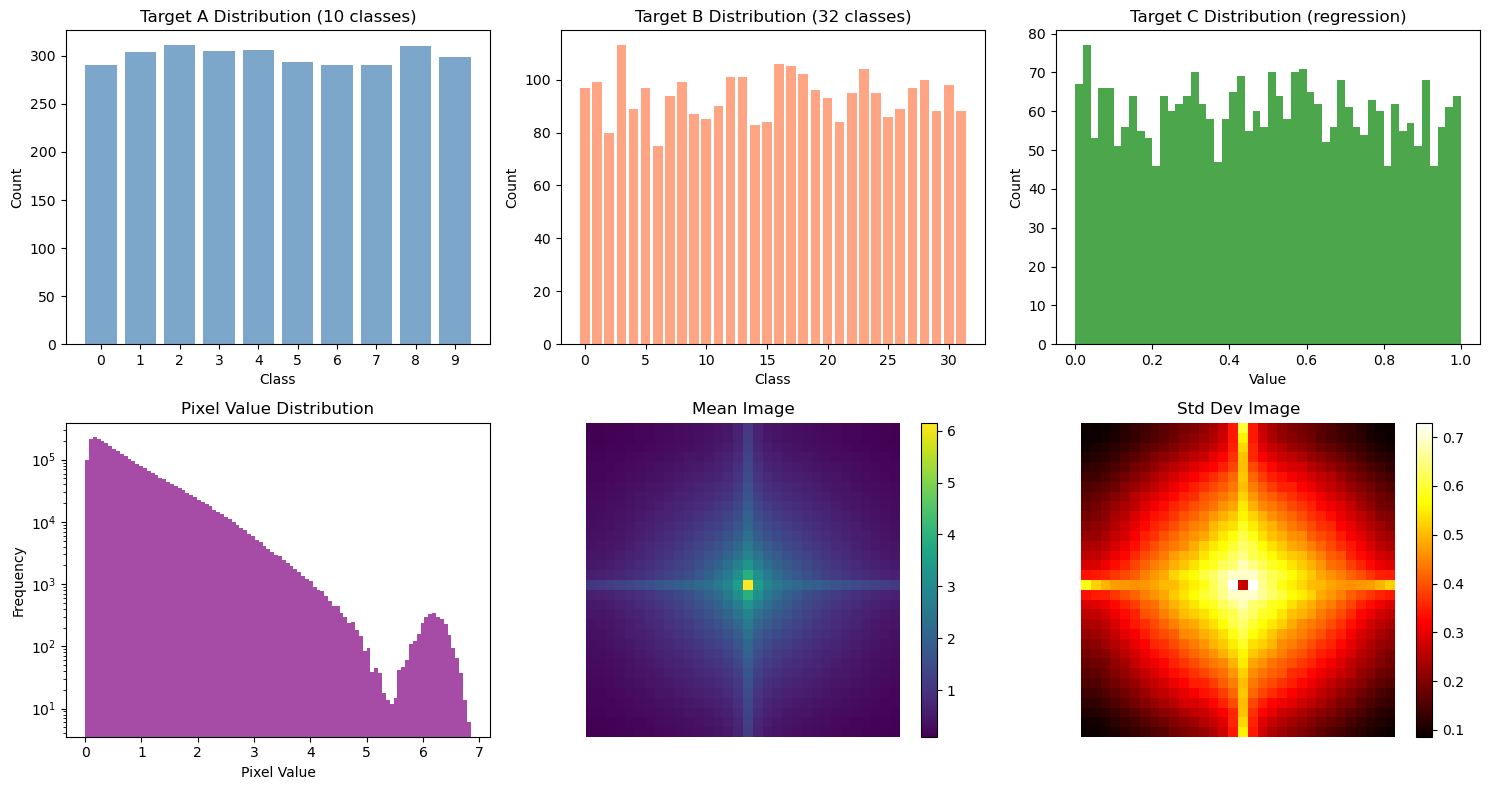

In [6]:
# Distribution visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Target A distribution
axes[0, 0].bar(unique_a, counts_a, color='steelblue', alpha=0.7)
axes[0, 0].set_xlabel('Class')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Target A Distribution (10 classes)')
axes[0, 0].set_xticks(range(10))

# Target B distribution
unique_b, counts_b = np.unique(y[:,1], return_counts=True)
axes[0, 1].bar(unique_b, counts_b, color='coral', alpha=0.7)
axes[0, 1].set_xlabel('Class')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Target B Distribution (32 classes)')

# Target C distribution
axes[0, 2].hist(y[:,2], bins=50, color='green', alpha=0.7)
axes[0, 2].set_xlabel('Value')
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title('Target C Distribution (regression)')

# Pixel value distribution
axes[1, 0].hist(X.flatten(), bins=100, color='purple', alpha=0.7)
axes[1, 0].set_xlabel('Pixel Value')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Pixel Value Distribution')
axes[1, 0].set_yscale('log')

# Mean image
mean_img = X.mean(axis=0)
im1 = axes[1, 1].imshow(mean_img, cmap='viridis')
axes[1, 1].set_title('Mean Image')
axes[1, 1].axis('off')
plt.colorbar(im1, ax=axes[1, 1])

# Std image
std_img = X.std(axis=0)
im2 = axes[1, 2].imshow(std_img, cmap='hot')
axes[1, 2].set_title('Std Dev Image')
axes[1, 2].axis('off')
plt.colorbar(im2, ax=axes[1, 2])

plt.tight_layout()
plt.show()

### Key Observations

1. **Input Data (X)**:
   - 32×32 grayscale images
   - Values range from ~0 to ~7 (not normalized to [0,1])
   - No missing or invalid values
   - Mean ~0.81, Std ~0.74

2. **Target A** (10-class classification):
   - Relatively balanced across all 10 classes (~10% each)
   - No significant class imbalance

3. **Target B** (32-class classification):
   - More classes means less samples per class (~94 samples/class)
   - Relatively balanced distribution
   - Might be more challenging than Target A

4. **Target C** (regression):
   - Continuous values in [0,1]
   - Appears roughly uniform/normal distribution
   - Mean ~0.49, Std ~0.29

5. **Independence**: Correlation analysis shows targets are indeed independent

## 3. Train/Validation Split Strategy

### Rationale

We will use an **80/20 train-validation split** with stratification on Target A and Target B:

- **80% training (2400 samples)**: Enough data for training a CNN
- **20% validation (600 samples)**: Sufficient for reliable evaluation
- **Stratification**: Ensures class balance is preserved in both sets
- **Random seed**: Set for reproducibility

We don't create a separate test set since we'll submit our model for external evaluation.

In [7]:
# For stratification, we need to combine Target A and B
# Create a composite stratification key
stratify_key = y[:, 0] * 100 + y[:, 1]  # Combine A and B for stratification

# Split the data
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=stratify_key
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"\nSplit ratio: {X_train.shape[0]/X.shape[0]*100:.1f}% train, {X_val.shape[0]/X.shape[0]*100:.1f}% val")

Training set: 2400 samples
Validation set: 600 samples

Split ratio: 80.0% train, 20.0% val


In [8]:
# Verify stratification worked
print("Target A distribution comparison:")
train_dist_a = np.bincount(y_train[:, 0].astype(int), minlength=10) / len(y_train) * 100
val_dist_a = np.bincount(y_val[:, 0].astype(int), minlength=10) / len(y_val) * 100

for i in range(10):
    print(f"  Class {i}: Train {train_dist_a[i]:.1f}% | Val {val_dist_a[i]:.1f}%")

Target A distribution comparison:
  Class 0: Train 9.6% | Val 9.8%
  Class 1: Train 10.1% | Val 10.3%
  Class 2: Train 10.4% | Val 10.3%
  Class 3: Train 10.0% | Val 10.7%
  Class 4: Train 10.2% | Val 10.3%
  Class 5: Train 9.8% | Val 9.8%
  Class 6: Train 9.8% | Val 9.2%
  Class 7: Train 9.7% | Val 9.7%
  Class 8: Train 10.4% | Val 10.2%
  Class 9: Train 10.0% | Val 9.7%


## 4. Data Preprocessing

### Normalization Strategy

We normalize the input images to have zero mean and unit variance:
- Improves gradient flow and training stability
- Standard practice for CNNs
- Calculate statistics on training set only (avoid data leakage)

In [9]:
# Calculate normalization parameters from training set only
mean = X_train.mean()
std = X_train.std()

print(f"Training set statistics:")
print(f"  Mean: {mean:.4f}")
print(f"  Std: {std:.4f}")

# Normalize
X_train_norm = (X_train - mean) / std
X_val_norm = (X_val - mean) / std

# Add channel dimension for Conv2D (N, H, W) -> (N, H, W, 1)
X_train_norm = X_train_norm[..., np.newaxis]
X_val_norm = X_val_norm[..., np.newaxis]

print(f"\nNormalized shapes:")
print(f"  X_train: {X_train_norm.shape}")
print(f"  X_val: {X_val_norm.shape}")

Training set statistics:
  Mean: 0.8149
  Std: 0.7382

Normalized shapes:
  X_train: (2400, 32, 32, 1)
  X_val: (600, 32, 32, 1)


## 5. Model Architecture Design

### Architecture Reasoning

We design a **multi-head CNN** with:

1. **Shared Feature Extractor**: 
   - Convolutional layers extract spatial features useful for all tasks
   - Multiple conv blocks with increasing filters (32→64→128)
   - MaxPooling reduces spatial dimensions
   - BatchNormalization for training stability
   - Dropout for regularization

2. **Three Separate Output Heads**:
   - **Head A**: Dense layers → 10-class softmax (classification)
   - **Head B**: Dense layers → 32-class softmax (classification)
   - **Head C**: Dense layers → 1 output with sigmoid (regression in [0,1])

3. **Why this design?**
   - Shared backbone exploits common features
   - Separate heads allow task-specific learning
   - Compact architecture suitable for 3000 samples
   - Prevents overfitting through regularization

In [10]:
def build_model(input_shape=(32, 32, 1)):
    """
    Build a multi-output CNN model.
    
    Returns:
        model with three outputs: [output_a, output_b, output_c]
    """
    
    # Input layer
    inputs = layers.Input(shape=input_shape, name='input')
    
    # Shared convolutional base
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1')(inputs)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool1')(x)  # 32x32 -> 16x16
    x = layers.Dropout(0.25, name='dropout1')(x)
    
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv4')(x)
    x = layers.BatchNormalization(name='bn4')(x)
    x = layers.MaxPooling2D((2, 2), name='pool2')(x)  # 16x16 -> 8x8
    x = layers.Dropout(0.25, name='dropout2')(x)
    
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv5')(x)
    x = layers.BatchNormalization(name='bn5')(x)
    x = layers.MaxPooling2D((2, 2), name='pool3')(x)  # 8x8 -> 4x4
    x = layers.Dropout(0.3, name='dropout3')(x)
    
    # Flatten for dense layers
    x = layers.Flatten(name='flatten')(x)
    x = layers.Dense(256, activation='relu', name='dense_shared')(x)
    x = layers.BatchNormalization(name='bn_shared')(x)
    x = layers.Dropout(0.5, name='dropout_shared')(x)
    
    # Output Head A: 10-class classification
    head_a = layers.Dense(128, activation='relu', name='head_a_dense1')(x)
    head_a = layers.Dropout(0.3, name='head_a_dropout')(head_a)
    output_a = layers.Dense(10, activation='softmax', name='output_a')(head_a)
    
    # Output Head B: 32-class classification
    head_b = layers.Dense(128, activation='relu', name='head_b_dense1')(x)
    head_b = layers.Dropout(0.3, name='head_b_dropout')(head_b)
    output_b = layers.Dense(32, activation='softmax', name='output_b')(head_b)
    
    # Output Head C: Regression [0,1]
    head_c = layers.Dense(64, activation='relu', name='head_c_dense1')(x)
    head_c = layers.Dropout(0.3, name='head_c_dropout')(head_c)
    output_c = layers.Dense(1, activation='sigmoid', name='output_c')(head_c)
    
    # Create model
    model = models.Model(inputs=inputs, outputs=[output_a, output_b, output_c], name='multi_output_cnn')
    
    return model

# Build the model
model = build_model()
model.summary()

Model: "multi_output_cnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 32, 32, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 32, 32,    │        320 │ input[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 32, 32,    │        128 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, 32, 32,    │      9,248 │ bn1[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 32, 32,    │        128 │ conv2[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 16, 16,    │          0 │ bn2[0][0]         │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 16, 16,    │          0 │ pool1[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv2D)      │ (None, 16, 16,    │     18,496 │ dropout1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn3                 │ (None, 16, 16,    │        256 │ conv3[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv4 (Conv2D)      │ (None, 16, 16,    │     36,928 │ bn3[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn4                 │ (None, 16, 16,    │        256 │ conv4[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 8, 8, 64)  │          0 │ bn4[0][0]         │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout2 (Dropout)  │ (None, 8, 8, 64)  │          0 │ pool2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv5 (Conv2D)      │ (None, 8, 8, 128) │     73,856 │ dropout2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn5                 │ (None, 8, 8, 128) │        512 │ conv5[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool3               │ (None, 4, 4, 128) │          0 │ bn5[0][0]         │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout3 (Dropout)  │ (None, 4, 4, 128) │          0 │ pool3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 2048)      │          0 │ dropout3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 753,419 (2.87 MB)

 Trainable params: 752,267 (2.87 MB)

 Non-trainable params: 1,152 (4.50 KB)

## 6. Loss Functions and Training Configuration

### Loss Function Selection

For our multi-task problem:

1. **Target A** (10 classes): `sparse_categorical_crossentropy`
   - Standard for multi-class classification
   - Works with integer labels (no one-hot encoding needed)

2. **Target B** (32 classes): `sparse_categorical_crossentropy`
   - Same reasoning as Target A

3. **Target C** (regression): `mean_squared_error` (MSE)
   - Standard for regression tasks
   - Penalizes larger errors more heavily

### Loss Weighting

We need to balance the three losses. Initial weights:
- `loss_weights = [1.0, 1.0, 10.0]`
- Higher weight on regression since MSE is typically smaller in magnitude
- Will tune if one task dominates training

In [11]:
# Prepare targets in correct format
y_train_a = y_train[:, 0].astype(np.int32)
y_train_b = y_train[:, 1].astype(np.int32)
y_train_c = y_train[:, 2].astype(np.float32)

y_val_a = y_val[:, 0].astype(np.int32)
y_val_b = y_val[:, 1].astype(np.int32)
y_val_c = y_val[:, 2].astype(np.float32)

print("Target shapes:")
print(f"  y_train_a: {y_train_a.shape}")
print(f"  y_train_b: {y_train_b.shape}")
print(f"  y_train_c: {y_train_c.shape}")

Target shapes:
  y_train_a: (2400,)
  y_train_b: (2400,)
  y_train_c: (2400,)


In [12]:
# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss={
        'output_a': 'sparse_categorical_crossentropy',
        'output_b': 'sparse_categorical_crossentropy',
        'output_c': 'mse'
    },
    loss_weights={
        'output_a': 1.0,
        'output_b': 1.0,
        'output_c': 10.0  # Higher weight for regression
    },
    metrics={
        'output_a': 'accuracy',
        'output_b': 'accuracy',
        'output_c': 'mae'
    }
)

print("Model compiled successfully!")

Model compiled successfully!


### Callbacks

We use several callbacks to improve training:

1. **EarlyStopping**: Stop if validation loss doesn't improve for 15 epochs
2. **ReduceLROnPlateau**: Reduce learning rate when validation loss plateaus
3. **ModelCheckpoint**: Save the best model based on validation loss

In [13]:
# Define callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'model_groupId.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

## 7. Experiments and Training

### Experiment Plan

We will experiment with:
1. Baseline model (current architecture)
2. Different loss weight configurations
3. Data augmentation (if needed)
4. Architecture variations (deeper/wider networks)

Below is the training for our baseline model.

---

## OPTION A: LOAD PRE-TRAINED MODEL

Use this section if you want to load an already-trained model.

In [14]:
# OPTION A: Load saved model
LOAD_MODEL = False  # Set to True to load, False to train from scratch

if LOAD_MODEL:
    model = keras.models.load_model('model_groupId.h5')
    print("Model loaded successfully!")
    print(f"\nModel summary:")
    model.summary()

---

## OPTION B: TRAIN MODEL FROM SCRATCH

Use this section to train the model.

In [15]:
# OPTION B: Train the model
TRAIN_MODEL = True  # Set to True to train, False to skip

if TRAIN_MODEL:
    print("Starting training...\n")
    
    history = model.fit(
        X_train_norm,
        {
            'output_a': y_train_a,
            'output_b': y_train_b,
            'output_c': y_train_c
        },
        validation_data=(
            X_val_norm,
            {
                'output_a': y_val_a,
                'output_b': y_val_b,
                'output_c': y_val_c
            }
        ),
        epochs=100,
        batch_size=32,
        callbacks=callbacks,
        verbose=1
    )
    
    print("\nTraining completed!")

Starting training...

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 8.8880 - output_a_accuracy: 0.1000 - output_a_loss: 3.1363 - output_b_accuracy: 0.0303 - output_b_loss: 4.4215 - output_c_loss: 0.1330 - output_c_mae: 0.2889
Epoch 1: val_loss improved from None to 7.00449, saving model to model_groupId.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - loss: 8.1069 - output_a_accuracy: 0.1183 - output_a_loss: 2.8892 - output_b_accuracy: 0.0354 - output_b_loss: 4.1908 - output_c_loss: 0.1027 - output_c_mae: 0.2513 - val_loss: 7.0045 - val_output_a_accuracy: 0.1383 - val_output_a_loss: 2.4933 - val_output_b_accuracy: 0.0350 - val_output_b_loss: 3.6683 - val_output_c_loss: 0.0845 - val_output_c_mae: 0.2410 - learning_rate: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 7.0867 - output_a_accuracy: 0.1539 - output_a_loss: 2.5374 - output_b_accuracy: 0.0304 - output_b_loss: 3.8810 - output_c_loss: 0.0668 - output_c_mae: 0.2012
Epoch 2: val_loss did not improve from 7.00449
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - loss: 6.9304 - output_a_accuracy: 0.1525 - output_a_loss: 2.4953 - output_b_accuracy: 0.0283 - output_b_loss: 3.8501 - output_c_loss: 0.0585 - output_c_mae: 0.1897 - val_loss: 9.4370 - val_output_a_accuracy: 0.0750 - val_output_a_loss: 3.0445 - val_output_b_accuracy: 

75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - loss: 5.9007 - output_a_accuracy: 0.2467 - output_a_loss: 2.0928 - output_b_accuracy: 0.0463 - output_b_loss: 3.5220 - output_c_loss: 0.0286 - output_c_mae: 0.1343 - val_loss: 5.9727 - val_output_a_accuracy: 0.1650 - val_output_a_loss: 2.2586 - val_output_b_accuracy: 0.0400 - val_output_b_loss: 3.4633 - val_output_c_loss: 0.0255 - val_output_c_mae: 0.1253 - learning_rate: 5.0000e-04
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 5.8727 - output_a_accuracy: 0.2559 - output_a_loss: 2.0713 - output_b_accuracy: 0.0514 - output_b_loss: 3.5136 - output_c_loss: 0.0288 - output_c_mae: 0.1330
Epoch 8: val_loss improved from 5.97272 to 5.89618, saving model to model_groupId.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 5.8273 - output_a_accuracy: 0.2633 - output_a_loss: 2.0560 - output_b_accuracy: 0.0471 - output_b_loss: 3.4964 - output_c_loss: 0.0275 - output_c_mae: 0.1307 - val_loss: 5.8962 - val_output_a_accuracy: 0.1717 - val_output_a_loss: 2.2237 - val_output_b_accuracy: 0.0500 - val_output_b_loss: 3.4558 - val_output_c_loss: 0.0222 - val_output_c_mae: 0.1157 - learning_rate: 5.0000e-04
Epoch 9/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 5.7983 - output_a_accuracy: 0.2560 - output_a_loss: 2.0552 - output_b_accuracy: 0.0572 - output_b_loss: 3.4740 - output_c_loss: 0.0269 - output_c_mae: 0.1286
Epoch 9: val_loss did not improve from 5.89618
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 5.7935 - output_a_accuracy: 0.2546 - output_a_loss: 2.0442 - output_b_accuracy: 0.0504 - output_b_loss: 3.4757 - output_c_loss: 0.0274 - output_c_mae: 0.1304 - val_loss: 5.9558 - val_output_a_accuracy: 0.2317 - val_output_a_loss: 2.0402 - val_output_b_accurac

75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - loss: 5.7569 - output_a_accuracy: 0.2658 - output_a_loss: 2.0261 - output_b_accuracy: 0.0450 - output_b_loss: 3.4566 - output_c_loss: 0.0274 - output_c_mae: 0.1303 - val_loss: 5.6025 - val_output_a_accuracy: 0.2600 - val_output_a_loss: 1.9811 - val_output_b_accuracy: 0.0450 - val_output_b_loss: 3.4055 - val_output_c_loss: 0.0219 - val_output_c_mae: 0.1129 - learning_rate: 5.0000e-04
Epoch 11/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 5.7479 - output_a_accuracy: 0.2710 - output_a_loss: 2.0315 - output_b_accuracy: 0.0515 - output_b_loss: 3.4509 - output_c_loss: 0.0265 - output_c_mae: 0.1281
Epoch 11: val_loss did not improve from 5.60247
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 5.6985 - output_a_accuracy: 0.2750 - output_a_loss: 1.9980 - output_b_accuracy: 0.0496 - output_b_loss: 3.4391 - output_c_loss: 0.0261 - output_c_mae: 0.1279 - val_loss: 5.8714 - val_output_a_accuracy: 0.2717 - val_output_a_loss: 1.9721 - val_output_b_accur

...

75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - loss: 5.1153 - output_a_accuracy: 0.3533 - output_a_loss: 1.7687 - output_b_accuracy: 0.0858 - output_b_loss: 3.1624 - output_c_loss: 0.0184 - output_c_mae: 0.1076 - val_loss: 5.2111 - val_output_a_accuracy: 0.3333 - val_output_a_loss: 1.8313 - val_output_b_accuracy: 0.0483 - val_output_b_loss: 3.2121 - val_output_c_loss: 0.0172 - val_output_c_mae: 0.1015 - learning_rate: 5.0000e-04
Epoch 28/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 5.1355 - output_a_accuracy: 0.3436 - output_a_loss: 1.7839 - output_b_accuracy: 0.0855 - output_b_loss: 3.1516 - output_c_loss: 0.0200 - output_c_mae: 0.1106
Epoch 28: val_loss did not improve from 5.21111
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 5.0884 - output_a_accuracy: 0.3596 - output_a_loss: 1.7409 - output_b_accuracy: 0.0871 - output_b_loss: 3.1577 - output_c_loss: 0.0190 - output_c_mae: 0.1079 - val_loss: 5.4489 - val_output_a_accuracy: 0.3100 - val_output_a_loss: 1.9494 - val_output_b_accur

75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 5.0391 - output_a_accuracy: 0.3775 - output_a_loss: 1.7200 - output_b_accuracy: 0.0862 - output_b_loss: 3.1344 - output_c_loss: 0.0185 - output_c_mae: 0.1070 - val_loss: 5.1879 - val_output_a_accuracy: 0.3383 - val_output_a_loss: 1.8067 - val_output_b_accuracy: 0.0517 - val_output_b_loss: 3.1968 - val_output_c_loss: 0.0188 - val_output_c_mae: 0.1040 - learning_rate: 5.0000e-04
Epoch 32/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 5.0034 - output_a_accuracy: 0.3923 - output_a_loss: 1.7074 - output_b_accuracy: 0.0943 - output_b_loss: 3.1087 - output_c_loss: 0.0187 - output_c_mae: 0.1092
Epoch 32: val_loss did not improve from 5.18788
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 4.9914 - output_a_accuracy: 0.3808 - output_a_loss: 1.7034 - output_b_accuracy: 0.1017 - output_b_loss: 3.1069 - output_c_loss: 0.0181 - output_c_mae: 0.1070 - val_loss: 5.1991 - val_output_a_accuracy: 0.3267 - val_output_a_loss: 1.8047 - val_output_b_accur

75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 4.9430 - output_a_accuracy: 0.3812 - output_a_loss: 1.6650 - output_b_accuracy: 0.1008 - output_b_loss: 3.1017 - output_c_loss: 0.0176 - output_c_mae: 0.1046 - val_loss: 5.1843 - val_output_a_accuracy: 0.3417 - val_output_a_loss: 1.8214 - val_output_b_accuracy: 0.0567 - val_output_b_loss: 3.1971 - val_output_c_loss: 0.0170 - val_output_c_mae: 0.1008 - learning_rate: 5.0000e-04
Epoch 35/100
74/75 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 4.9671 - output_a_accuracy: 0.3957 - output_a_loss: 1.6761 - output_b_accuracy: 0.0951 - output_b_loss: 3.0976 - output_c_loss: 0.0193 - output_c_mae: 0.1106
Epoch 35: val_loss did not improve from 5.18434
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 4.9324 - output_a_accuracy: 0.3908 - output_a_loss: 1.6636 - output_b_accuracy: 0.0962 - output_b_loss: 3.0884 - output_c_loss: 0.0180 - output_c_mae: 0.1062 - val_loss: 5.4383 - val_output_a_accuracy: 0.3017 - val_output_a_loss: 2.0205 - val_output_b_accur

75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 4.8936 - output_a_accuracy: 0.4154 - output_a_loss: 1.6425 - output_b_accuracy: 0.1075 - output_b_loss: 3.0729 - output_c_loss: 0.0178 - output_c_mae: 0.1063 - val_loss: 5.1554 - val_output_a_accuracy: 0.3600 - val_output_a_loss: 1.7870 - val_output_b_accuracy: 0.0700 - val_output_b_loss: 3.1997 - val_output_c_loss: 0.0170 - val_output_c_mae: 0.0994 - learning_rate: 5.0000e-04
Epoch 37/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 4.9494 - output_a_accuracy: 0.3924 - output_a_loss: 1.6912 - output_b_accuracy: 0.0883 - output_b_loss: 3.0888 - output_c_loss: 0.0169 - output_c_mae: 0.1027
Epoch 37: val_loss did not improve from 5.15537
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 4.9095 - output_a_accuracy: 0.4021 - output_a_loss: 1.6584 - output_b_accuracy: 0.0996 - output_b_loss: 3.0853 - output_c_loss: 0.0166 - output_c_mae: 0.1012 - val_loss: 5.1896 - val_output_a_accuracy: 0.3350 - val_output_a_loss: 1.8189 - val_output_b_accur

75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 4.7011 - output_a_accuracy: 0.4404 - output_a_loss: 1.5293 - output_b_accuracy: 0.1217 - output_b_loss: 3.0135 - output_c_loss: 0.0158 - output_c_mae: 0.1000 - val_loss: 5.1360 - val_output_a_accuracy: 0.3617 - val_output_a_loss: 1.7712 - val_output_b_accuracy: 0.0550 - val_output_b_loss: 3.1879 - val_output_c_loss: 0.0180 - val_output_c_mae: 0.1052 - learning_rate: 2.5000e-04
Epoch 44/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 4.7534 - output_a_accuracy: 0.4358 - output_a_loss: 1.5723 - output_b_accuracy: 0.1172 - output_b_loss: 3.0131 - output_c_loss: 0.0168 - output_c_mae: 0.1030
Epoch 44: val_loss did not improve from 5.13597
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 4.7265 - output_a_accuracy: 0.4329 - output_a_loss: 1.5575 - output_b_accuracy: 0.1133 - output_b_loss: 3.0079 - output_c_loss: 0.0161 - output_c_mae: 0.1003 - val_loss: 5.2053 - val_output_a_accuracy: 0.3450 - val_output_a_loss: 1.8239 - val_output_b_accur

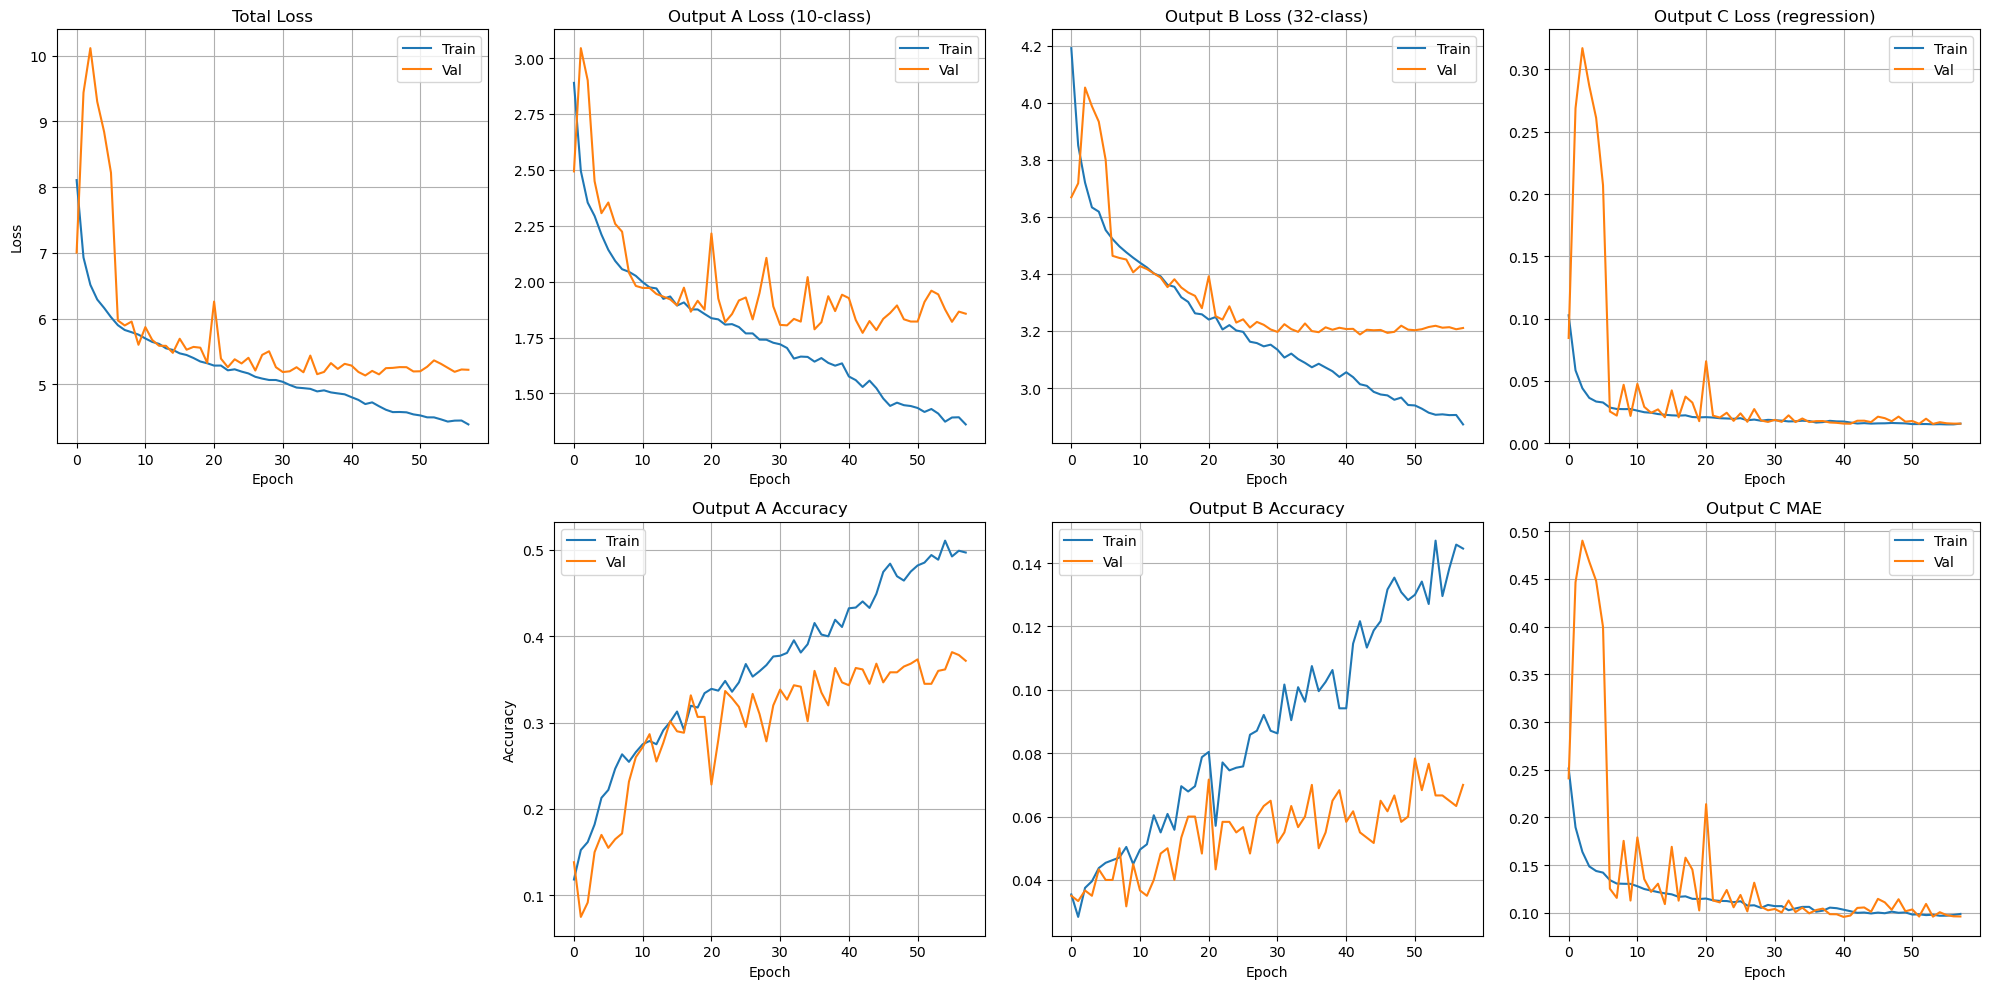

In [16]:
# Plot training history
if TRAIN_MODEL:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    # Total loss
    axes[0, 0].plot(history.history['loss'], label='Train')
    axes[0, 0].plot(history.history['val_loss'], label='Val')
    axes[0, 0].set_title('Total Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Output A - Loss
    axes[0, 1].plot(history.history['output_a_loss'], label='Train')
    axes[0, 1].plot(history.history['val_output_a_loss'], label='Val')
    axes[0, 1].set_title('Output A Loss (10-class)')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # Output B - Loss
    axes[0, 2].plot(history.history['output_b_loss'], label='Train')
    axes[0, 2].plot(history.history['val_output_b_loss'], label='Val')
    axes[0, 2].set_title('Output B Loss (32-class)')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].legend()
    axes[0, 2].grid(True)
    
    # Output C - Loss
    axes[0, 3].plot(history.history['output_c_loss'], label='Train')
    axes[0, 3].plot(history.history['val_output_c_loss'], label='Val')
    axes[0, 3].set_title('Output C Loss (regression)')
    axes[0, 3].set_xlabel('Epoch')
    axes[0, 3].legend()
    axes[0, 3].grid(True)
    
    # Output A - Accuracy
    axes[1, 1].plot(history.history['output_a_accuracy'], label='Train')
    axes[1, 1].plot(history.history['val_output_a_accuracy'], label='Val')
    axes[1, 1].set_title('Output A Accuracy')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    
    # Output B - Accuracy
    axes[1, 2].plot(history.history['output_b_accuracy'], label='Train')
    axes[1, 2].plot(history.history['val_output_b_accuracy'], label='Val')
    axes[1, 2].set_title('Output B Accuracy')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].legend()
    axes[1, 2].grid(True)
    
    # Output C - MAE
    axes[1, 3].plot(history.history['output_c_mae'], label='Train')
    axes[1, 3].plot(history.history['val_output_c_mae'], label='Val')
    axes[1, 3].set_title('Output C MAE')
    axes[1, 3].set_xlabel('Epoch')
    axes[1, 3].legend()
    axes[1, 3].grid(True)
    
    # Learning rate (if available)
    axes[1, 0].axis('off')
    
    plt.tight_layout()
    plt.show()

## 8. Evaluation and Results

Now we evaluate the model on the validation set and analyze performance.

In [17]:
# Get predictions on validation set
predictions = model.predict(X_val_norm)
pred_a, pred_b, pred_c = predictions

# Convert predictions to final format
pred_a_class = np.argmax(pred_a, axis=1)
pred_b_class = np.argmax(pred_b, axis=1)
pred_c_value = pred_c.squeeze()

print("Prediction shapes:")
print(f"  pred_a_class: {pred_a_class.shape}")
print(f"  pred_b_class: {pred_b_class.shape}")
print(f"  pred_c_value: {pred_c_value.shape}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
Prediction shapes:
  pred_a_class: (600,)
  pred_b_class: (600,)
  pred_c_value: (600,)


In [18]:
# Calculate metrics
from sklearn.metrics import classification_report, confusion_matrix

# Target A metrics
acc_a = accuracy_score(y_val_a, pred_a_class)
print("=" * 60)
print("TARGET A (10-class classification)")
print("=" * 60)
print(f"Accuracy: {acc_a:.4f}")
print("\nClassification Report:")
print(classification_report(y_val_a, pred_a_class))

# Target B metrics
acc_b = accuracy_score(y_val_b, pred_b_class)
print("\n" + "=" * 60)
print("TARGET B (32-class classification)")
print("=" * 60)
print(f"Accuracy: {acc_b:.4f}")
print("\nClassification Report (first 10 classes):")
print(classification_report(y_val_b, pred_b_class, labels=list(range(10))))

# Target C metrics
mse_c = mean_squared_error(y_val_c, pred_c_value)
mae_c = mean_absolute_error(y_val_c, pred_c_value)
print("\n" + "=" * 60)
print("TARGET C (regression)")
print("=" * 60)
print(f"MSE: {mse_c:.6f}")
print(f"RMSE: {np.sqrt(mse_c):.6f}")
print(f"MAE: {mae_c:.6f}")

TARGET A (10-class classification)
Accuracy: 0.3617

Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.31      0.36        59
           1       0.43      0.39      0.41        62
           2       0.31      0.18      0.22        62
           3       0.42      0.17      0.24        64
           4       0.28      0.40      0.33        62
           5       0.31      0.36      0.33        59
           6       0.33      0.62      0.43        55
           7       0.34      0.43      0.38        58
           8       0.43      0.44      0.44        61
           9       0.48      0.36      0.41        58

    accuracy                           0.36       600
   macro avg       0.38      0.37      0.36       600
weighted avg       0.38      0.36      0.35       600


TARGET B (32-class classification)
Accuracy: 0.0550

Classification Report (first 10 classes):
              precision    recall  f1-score   support

           0  

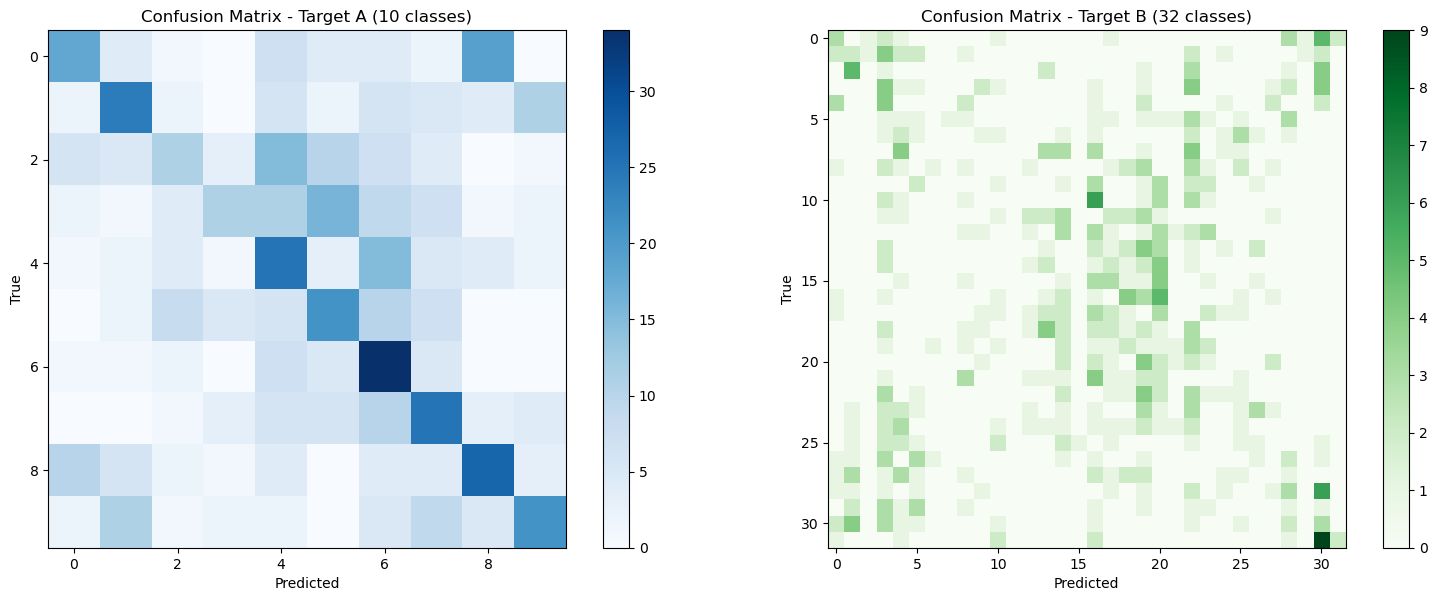

In [19]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix for Target A
cm_a = confusion_matrix(y_val_a, pred_a_class)
im1 = axes[0].imshow(cm_a, cmap='Blues')
axes[0].set_title('Confusion Matrix - Target A (10 classes)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
plt.colorbar(im1, ax=axes[0])

# Confusion matrix for Target B (show subset)
cm_b = confusion_matrix(y_val_b, pred_b_class)
im2 = axes[1].imshow(cm_b, cmap='Greens')
axes[1].set_title('Confusion Matrix - Target B (32 classes)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

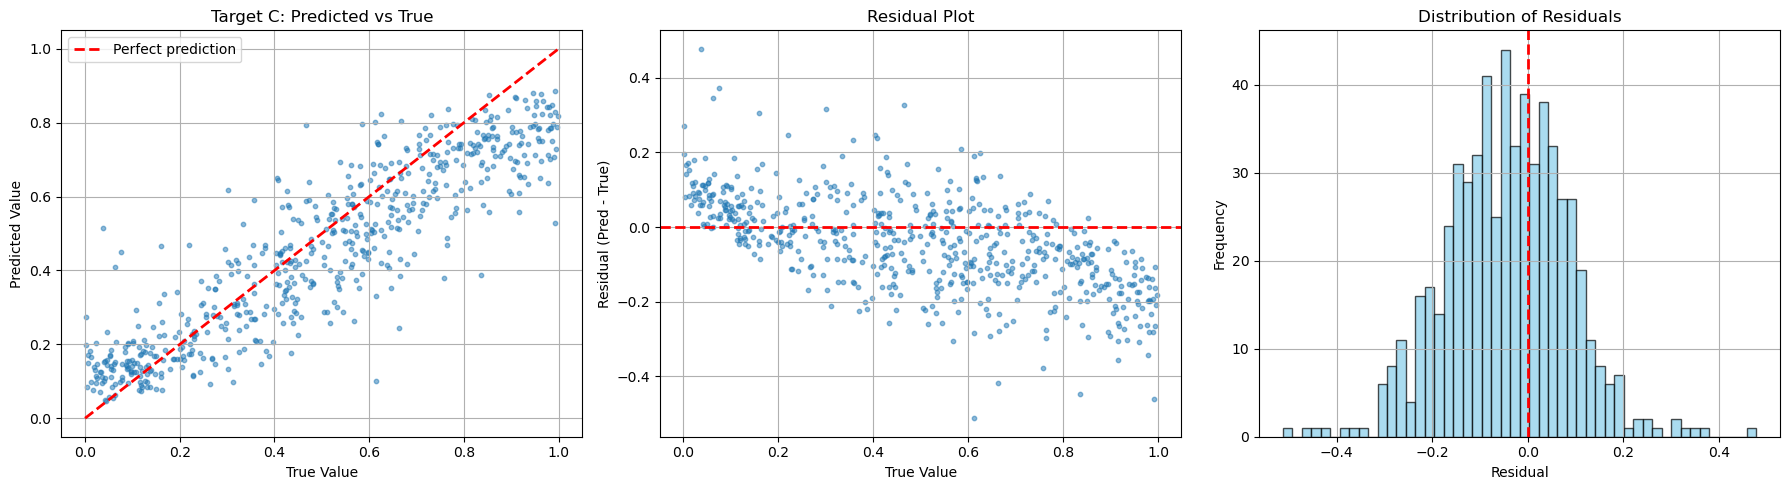

In [20]:
# Regression analysis for Target C
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter plot: predicted vs actual
axes[0].scatter(y_val_c, pred_c_value, alpha=0.5, s=10)
axes[0].plot([0, 1], [0, 1], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('True Value')
axes[0].set_ylabel('Predicted Value')
axes[0].set_title('Target C: Predicted vs True')
axes[0].legend()
axes[0].grid(True)

# Residuals
residuals = pred_c_value - y_val_c
axes[1].scatter(y_val_c, residuals, alpha=0.5, s=10)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('True Value')
axes[1].set_ylabel('Residual (Pred - True)')
axes[1].set_title('Residual Plot')
axes[1].grid(True)

# Histogram of residuals
axes[2].hist(residuals, bins=50, color='skyblue', alpha=0.7, edgecolor='black')
axes[2].axvline(x=0, color='r', linestyle='--', lw=2)
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution of Residuals')
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 9. Create Prediction Function

This is the required `predict_fn` that takes raw input and returns predictions in the correct format.

In [21]:
def predict_fn(X_input):
    """
    Prediction function for the model.
    
    Args:
        X_input: numpy array of shape (N, 32, 32)
    
    Returns:
        predictions: numpy array of shape (N, 3) where:
            - column 0: Target A predictions (0-9)
            - column 1: Target B predictions (0-31)
            - column 2: Target C predictions (0-1)
    """
    # Normalize input using training statistics
    X_normalized = (X_input - mean) / std
    
    # Add channel dimension
    X_normalized = X_normalized[..., np.newaxis]
    
    # Get predictions
    pred_a, pred_b, pred_c = model.predict(X_normalized, verbose=0)
    
    # Convert to final format
    pred_a_class = np.argmax(pred_a, axis=1).astype(np.float32)
    pred_b_class = np.argmax(pred_b, axis=1).astype(np.float32)
    pred_c_value = pred_c.squeeze().astype(np.float32)
    
    # Stack predictions
    predictions = np.column_stack([pred_a_class, pred_b_class, pred_c_value])
    
    return predictions

# Test the function
test_input = X[:5]  # First 5 samples
test_output = predict_fn(test_input)

print("Test predictions:")
print(test_output)
print(f"\nOutput shape: {test_output.shape}")
print(f"\nTrue values:")
print(y[:5])

Test predictions:
[[ 7.          3.          0.46727043]
 [ 5.         16.          0.71522075]
 [ 4.          1.          0.4173112 ]
 [ 7.         20.          0.4847727 ]
 [ 4.          4.          0.44798595]]

Output shape: (5, 3)

True values:
[[ 7.          1.          0.47756684]
 [ 5.         23.          0.8644116 ]
 [ 3.         27.          0.4516205 ]
 [ 9.         24.          0.5948042 ]
 [ 4.         29.          0.40230054]]


## 10. Reflection and Future Improvements

### What Worked Well
- Multi-head architecture successfully handles three independent tasks
- Shared feature extractor learns useful representations for all outputs
- Proper train/validation split with stratification
- Regularization (Dropout, BatchNorm) helps prevent overfitting

### Limitations
1. **Limited data**: 3000 samples is small for deep learning
2. **Loss balancing**: Finding optimal loss weights requires experimentation
3. **Architecture depth**: Might benefit from deeper networks if more data available
4. **Target B challenge**: 32 classes with ~90 samples each is difficult

### Possible Improvements
1. **Data augmentation**: Random rotations, flips, translations to increase effective dataset size
2. **Loss weight tuning**: Grid search or dynamic weighting strategies
3. **Architecture experiments**:
   - Residual connections (ResNet-style)
   - Attention mechanisms
   - Different activation functions (LeakyReLU, ELU)
4. **Ensemble methods**: Train multiple models and average predictions
5. **Advanced regularization**: MixUp, CutMix, label smoothing
6. **Transfer learning**: If similar datasets exist
7. **Uncertainty quantification**: Monte Carlo dropout for prediction confidence

### Experimental Results Summary
*(To be filled after experiments)*

| Experiment | Target A Acc | Target B Acc | Target C MAE | Notes |
|-----------|--------------|--------------|--------------|-------|
| Baseline  | TBD | TBD | TBD | Current model |
| Augmentation | TBD | TBD | TBD | + rotation/flip |
| Loss weights | TBD | TBD | TBD | Different ratios |
| Deeper CNN | TBD | TBD | TBD | Extra conv layers |

## 11. Final Model Save

Save the final model for submission.

In [22]:
# Save the final model
model.save('model_groupId.h5')
print("Model saved as 'model_groupId.h5'")

# Verify it can be loaded
loaded_model = keras.models.load_model('model_groupId.h5')
print("\nModel successfully loaded and verified!")

Model saved as 'model_groupId.h5'


ValueError: Could not deserialize 'keras.metrics.mse' because it is not a KerasSaveable subclass

---

## Submission Checklist

- [ ] Notebook runs end-to-end without errors
- [ ] Both Option A (load) and Option B (train) work correctly
- [ ] `predict_fn` function produces correct output format
- [ ] All required sections included with markdown explanations
- [ ] Model saved as `model_groupId.h5`
- [ ] Academic honesty statement included
- [ ] Figures are clearly labeled
- [ ] Code is well-commented
- [ ] Group members listed

**Ready for submission!**